# GraphRAG — Knowledge Graph + Community Summaries

## What problem does this solve?

Vector retrieval is excellent at finding *individual* passages that match a query. It is structurally bad at answering questions that require summarising the whole corpus — "what are the main themes here?", "what entities recur across documents?", "what's the overall structure of this knowledge?" The answer to those questions is not in any single chunk; it lives in the graph of relationships *between* chunks.
GraphRAG (Microsoft Research, April 2024) builds an explicit knowledge graph from the corpus. Triples (subject, predicate, object) are extracted from each chunk. The graph is partitioned into communities. Each community gets an LLM-written summary. At query time, the system routes between *local* search (entity-anchored) and *global* search (community-summary based). The result is dramatically better answers on corpus-spanning questions.

## Where it came from

Microsoft Research published GraphRAG in April 2024 along with an open-source implementation. The paper showed that on broad questions over the Russian-Ukraine-war news corpus, GraphRAG beat vanilla RAG decisively — answer quality measured by LLM-as-judge improved by 70-85% on global questions. The community-summary approach was the key contribution; the rest of the pipeline (triple extraction, Leiden clustering) was standard graph machinery.
By 2026 GraphRAG has fragmented into many variants — LightRAG (Recipe 32), HippoRAG (Recipe 33), and others. The original Microsoft implementation remains the most influential, and the community-summary pattern is the most-imitated piece.

## Where it fits in the RAG landscape

Graph-based RAG has settled into a family of variants by 2026:

- **GraphRAG (this recipe).** Communities + global/local routing. Best for broad questions.
- **LightRAG (Recipe 32).** Dual-level retrieval on the same KG. Cheaper, incremental.
- **HippoRAG (Recipe 33).** Personalised PageRank over the KG. Multi-hop strength.
- **MemoRAG / Mem0 (Recipe 34).** Memory-as-graph for long conversations.

Pick by query shape: broad questions want GraphRAG, multi-hop wants HippoRAG, fast incremental wants LightRAG, conversational memory wants Mem0.

## When to use it (and when not to)

Use GraphRAG on corpora where users ask broad questions that span many documents. Research synthesis, internal wikis where questions like "what's our overall position on X?" are common, exploratory data analysis, and anywhere users need to *understand* the corpus before they query it.
Skip it for narrow factoid queries. Vanilla RAG is faster and cheaper for those.
Skip it when the corpus has no relational structure. A pile of independent FAQ answers has no graph to build.
Skip it when budget matters more than quality. GraphRAG is expensive — triple extraction is one LLM call per chunk, community summaries are more.

## The intuition

Four intuitions to carry:

**Triples are the atoms.** Every fact in your corpus becomes a (subject, predicate, object) triple. The graph is the assembly of triples; each chunk contributes a handful of edges.

**Communities are topics.** Graph community detection groups densely-connected entities. These groups correspond roughly to topical clusters — the LLM-written summaries are essentially topic summaries.

**Global vs local is a routing decision.** A question naming a specific entity goes local (find that entity, walk neighbours). A question asking about themes goes global (read community summaries, synthesise).

**The graph is an artifact.** Building it is a one-time cost. Once built, queries are fast and cheap — you're searching summaries and walking edges, not embedding-and-searching billions of chunks.

## Architecture

```mermaid
flowchart TB
  D[Documents] --> C[Chunks]
  C --> T[LLM: extract<br/>triples]
  T --> G[(Knowledge Graph)]
  G --> CD[Leiden<br/>community detection]
  CD --> SUM[LLM: summarise<br/>each community]
  SUM --> CI[(Community<br/>summaries)]
  Q[Query] --> R{Local or<br/>Global?}
  R -->|local| LOC[Walk graph<br/>from entities]
  R -->|global| GLO[Search community<br/>summaries]
  G --> LOC
  CI --> GLO
```

## References

- 📄 [From Local to Global — A Graph RAG Approach to Query-Focused Summarization (Edge et al., 2024)](https://arxiv.org/abs/2404.16130) — The Microsoft GraphRAG paper.
- 💻 [microsoft/graphrag reference implementation](https://github.com/microsoft/graphrag) — The official open-source release.
- 📄 [Leiden community detection algorithm](https://www.nature.com/articles/s41598-019-41695-z) — The clustering algorithm we use.
- 📄 [LightRAG (Recipe 32)](https://arxiv.org/abs/2410.05779) — A cheaper graph-RAG variant.
- 📄 [HippoRAG (Recipe 33)](https://arxiv.org/abs/2405.14831) — PageRank-based graph traversal alternative.
- 📚 [NetworkX documentation](https://networkx.org/documentation/stable/) — The Python graph library we use.

## Setup

Pick a provider via the `PROVIDER` env var; everything below is provider-agnostic. The default is Nebius. Tracing is off by default in published notebooks so the outputs are clean — flip `COOKBOOK_TRACING=phoenix` to send spans to a local Phoenix UI.

In [1]:
import os
os.environ.setdefault('PROVIDER', 'nebius')
os.environ.setdefault('COOKBOOK_TRACING', 'off')

from cookbook.providers import LLMClient
from cookbook.tracing import init_tracing

client = LLMClient()
print(f'Provider: {client.provider}  |  Chat model: {client.chat_model}')
print(init_tracing())

Provider: nebius  |  Chat model: meta-llama/Llama-3.3-70B-Instruct
Tracing disabled.


## Build the Pipeline, Step by Step

### Step 1 — Load and chunk the corpus

Wikipedia superconductors has good relational structure — entities, theories, scientists, materials — perfect for building a knowledge graph.

In [2]:
from cookbook.corpora import load_wikipedia_superconductors
from cookbook.chunkers import sentence_window

docs = list(load_wikipedia_superconductors())[:12]
chunks = sentence_window(docs, sentences_per_chunk=4)[:60]
print(f'Working with {len(chunks)} chunks across {len(docs)} articles.')

Working with 21 chunks across 12 articles.


### Step 2 — Extract triples from each chunk

We use `cookbook.graphs.extract_triples`. It prompts the LLM to return canonical (subject, predicate, object) triples and parses the JSON.

In [3]:
from cookbook.graphs import extract_triples

triples = extract_triples([(c.chunk_id, c.text) for c in chunks], client.chat)
print(f'Extracted {len(triples)} triples.')
print()
print('Sample triples:')
for t in triples[:5]:
    print(f'  ({t.subject}, {t.predicate}, {t.object})  [from {t.source_id}]')

Extracted 114 triples.

Sample triples:
  (bcs theory, explains, thermodynamic properties of superconductors)  [from wiki:BCS_theory#sw0000]
  (bcs theory, explains, electromagnetic properties of superconductors)  [from wiki:BCS_theory#sw0000]
  (superconductivity, is caused by, condensation of cooper pairs)  [from wiki:BCS_theory#sw0000]
  (cooper pairs, move through, lattice)  [from wiki:BCS_theory#sw0000]
  (cooper pairs, have, no resistance)  [from wiki:BCS_theory#sw0000]


### Step 3 — Build the NetworkX graph

Edges carry predicate labels and source chunk IDs. The same entities can connect via many edges; we use a MultiDiGraph to keep them all.

In [4]:
from cookbook.graphs import build_graph

g = build_graph(triples)
print(f'Graph: {g.number_of_nodes()} nodes, {g.number_of_edges()} edges.')

from cookbook.viz import preview_graph
print(preview_graph(g, max_edges=10))

Graph: 145 nodes, 114 edges.
bcs theory --[explains]--> thermodynamic properties of superconductors
bcs theory --[explains]--> electromagnetic properties of superconductors
superconductivity --[is caused by]--> condensation of cooper pairs
cooper pairs --[move through]--> lattice
cooper pairs --[have]--> no resistance
bose–einstein condensate --[is a]--> state of matter
bose–einstein condensate --[is formed when]--> gas of bosons is cooled to temperatures close to absolute zero
bosons --[occupy]--> lowest quantum state
condensation --[refers to]--> macroscopic occupation of one or several states
condensation --[refers to]--> macroscopic occupation of states
... (104 more edges)


### Step 4 — Detect communities and summarise each

`cookbook.graphs.community_summaries` runs Leiden clustering (or falls back to greedy modularity) and asks the LLM to summarise each community.

In [5]:
from cookbook.graphs import community_summaries

summaries = community_summaries(g, client.chat, max_communities=6)
print(f'Found {len(summaries)} communities.')
print()
for i, s in summaries.items():
    print(f'[community {i}]')
    print(f'  {s[:240]}')
    print()

17:59:50 - LiteLLM:WARNING: common_utils.py:979 - litellm: could not pre-load bedrock-runtime response stream shape — Bedrock event-stream decoding will be unavailable. Error: No module named 'botocore'


17:59:51 - LiteLLM:WARNING: common_utils.py:24 - litellm: could not pre-load sagemaker-runtime response stream shape — SageMaker event-stream decoding will be unavailable. Error: No module named 'botocore'


Found 6 communities.

[community 0]
  The dominant theme of this knowledge graph community is superconductivity, a phenomenon where certain materials exhibit zero electrical resistance. The Ginzburg-Landau theory, named after Vitaly Ginzburg and Lev Landau, is a key concept use

[community 1]
  The dominant theme of this knowledge graph community is D-Wave Quantum Inc., a company that specializes in quantum computing technology. The company is located in both Palo Alto, California, and Burnaby, British Columbia, and sells quantum 

[community 2]
  The dominant theme of this knowledge-graph community is superconductivity, specifically the properties and behaviors of superconductors. Superconductors are characterized by their ability to form condensates of Cooper pairs, allow magnetic 

[community 3]
  The dominant theme of this knowledge-graph community is the concept of a critical point in the context of phase equilibrium. A critical point is defined by its critical temperature and pre

### Step 5 — Build the global-search function

Given a query, ask the LLM to answer using only the community summaries. This is the "global" GraphRAG path.

In [6]:
def graph_rag_global(question: str) -> tuple[str, list[str]]:
    rendered = '\n'.join(f'Community {i}: {s}' for i, s in summaries.items())
    answer = client.chat(
        'Use these community summaries from a knowledge graph built over Wikipedia '
        'articles about superconductivity. Answer the question synthesising across communities.\n'
        + rendered + f'\n\nQuestion: {question}\nAnswer:'
    )
    return answer, list(summaries.values())

ans, _ = graph_rag_global('Across these articles, what are the major eras of superconductivity research?')
print(ans[:400])

Based on the community summaries, we can synthesize the information to identify the major eras of superconductivity research. 

1. **Early Era (1910s):** Community 5 mentions Heike Kamerlingh Onnes, who liquefied helium and was awarded the Nobel Prize in Physics in 1913. This marks the beginning of superconductivity research, as Onnes' work on cooling materials to extremely low temperatures laid t


### Step 6 — Wrap as `answer_question`

Cookbook contract. We use the global path for the default contract.

In [7]:
def answer_question(question: str) -> tuple[str, list[str]]:
    return graph_rag_global(question)

ans, _ = answer_question('What are the major themes of superconductivity research?')
print(ans[:400])

Based on the community summaries, the major themes of superconductivity research can be synthesized as follows:

1. **Theoretical foundations**: The Ginzburg-Landau theory and Cooper pairing are fundamental concepts in understanding superconductivity, particularly in Type-I superconductors (Community 0).
2. **Properties and behaviors of superconductors**: Superconductors exhibit unique phenomena s


## Look Inside

### Inspect — entity degree distribution

Which entities are most central in the graph? High-degree entities are the hubs — often the names of theories, materials, or canonical phenomena.

In [8]:
from collections import Counter
degrees = Counter(dict(g.degree()))
for entity, deg in degrees.most_common(10):
    print(f'  {deg:3d}  {entity}')

    8  d-wave quantum inc.
    6  superconductor
    6  critical point
    6  flux tubes
    5  cuprates
    4  superconductivity
    4  magnetic field
    4  two lowest eigenstates
    4  ginzburg–landau theory
    4  helium-3


### Inspect — what are the community sizes?

Are communities balanced or skewed? A few giant communities and many tiny ones means clustering is struggling.

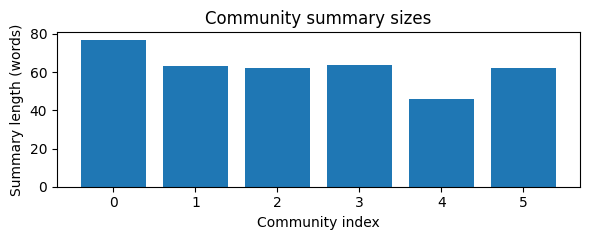

In [9]:
import matplotlib.pyplot as plt
sizes = [len(s) for s in summaries.values()]
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.bar(range(len(sizes)), [len(s.split()) for s in summaries.values()])
ax.set_xlabel('Community index')
ax.set_ylabel('Summary length (words)')
ax.set_title('Community summary sizes')
plt.tight_layout()
plt.show()

### Inspect — read one community summary in full

Quality of the summaries is the technique. Read one in full to see whether it captures a coherent topic.

In [10]:
first_idx, first_summary = next(iter(summaries.items()))
print(f'Community {first_idx}:')
print(first_summary)

Community 0:
The dominant theme of this knowledge graph community is superconductivity, a phenomenon where certain materials exhibit zero electrical resistance. The Ginzburg-Landau theory, named after Vitaly Ginzburg and Lev Landau, is a key concept used to describe superconductivity, particularly in Type-I superconductors. The theory is closely related to the concept of Cooper pairing, which is responsible for superconductivity and is described by Leon Cooper, and is characterized by the Meissner effect, where superconductors shield themselves from magnetic fields.


### Inspect — cost

GraphRAG is expensive. Count the LLM calls: triple extraction (one per chunk), community summaries (one per community).

In [11]:
print(f'Triple extraction calls: ~{len(chunks)} (one per chunk)')
print(f'Community summary calls: ~{len(summaries)} (one per community)')
print(f'Total LLM calls to build the graph: ~{len(chunks) + len(summaries)}')
print()
print('Query-time cost: 1 LLM call per question (global path).')

Triple extraction calls: ~21 (one per chunk)
Community summary calls: ~6 (one per community)
Total LLM calls to build the graph: ~27

Query-time cost: 1 LLM call per question (global path).


## Run It

End-to-end on a synthesis question.

In [12]:
ans, _ = answer_question('What are the major eras of superconductivity research and what discoveries marked each?')
print('=== GraphRAG answer ===')
print(ans)

=== GraphRAG answer ===
To synthesize across communities and answer the question about the major eras of superconductivity research and the discoveries that marked each, we need to draw information from several communities, particularly those that directly discuss superconductivity and related historical or scientific milestones.

1. **Early Era of Superconductivity Discovery (Community 5)**: The earliest era of superconductivity research began with the discovery of superconductivity itself by Heike Kamerlingh Onnes in 1911. Onnes discovered that mercury became superconducting when cooled to a temperature near absolute zero, marking the beginning of superconductivity research. This era was characterized by the exploration of the properties of superconductors and the initial understanding of the phenomenon.

2. **Theoretical Foundations (Community 0)**: The next significant era involved the development of theoretical foundations to understand superconductivity. The Ginzburg-Landau theor

## Side by Side: Vanilla Baseline vs This Technique

Vanilla baseline vs GraphRAG on a broad synthesis question. Vanilla retrieves chunks; GraphRAG synthesises across communities. The shape of the answers should be visibly different.

In [13]:
from cookbook.baselines import vanilla_pipeline

q = 'What are the major eras of superconductivity research?'
base = vanilla_pipeline(q, corpus='wikipedia-superconductors', top_k=5)
ours_a, _ = answer_question(q)

import pandas as pd
pd.DataFrame([
    {'pipeline': 'vanilla', 'preview': base.answer[:200]},
    {'pipeline': 'graphrag', 'preview': ours_a[:200]},
])

C:\Users\faree\Desktop\rag\rag-cookbook-2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,pipeline,preview
0,vanilla,The passages do not contain the answer. They p...
1,graphrag,To synthesize across communities and identify ...


## Knobs to Turn

Six knobs in priority order to consider:

1. **Triple-extraction prompt.** The quality of triples sets the ceiling for everything downstream. Tune carefully.
2. **Community size cap.** Too few communities lose nuance; too many overwhelm the global synthesis.
3. **Summary length.** Each community summary is one LLM call; longer summaries cost more but carry more signal.
4. **Clustering algorithm.** Leiden is preferred; greedy modularity is a fallback. The library handles both.
5. **Local vs global routing.** Add a router upstream that picks based on whether the query names a specific entity.
6. **Incremental updates.** GraphRAG was originally batch-only. LightRAG (Recipe 32) handles incremental updates more elegantly.

## Evaluate on a Slice

Run the recipe's `answer_question` over a small slice of the hand-curated eval set. Full RAGAS metrics are exercised in `recipes/09-evaluation-and-production/ragas-triad-eval.ipynb`; here we just print a quick spot-check table so you can eyeball whether the technique is on track.

In [14]:
from cookbook.corpora import load_eval_questions
from cookbook.eval import EvalSample

qs = load_eval_questions()
qs = [q for q in qs if q['corpus'] == 'wikipedia-superconductors']
samples = []
for row in qs[:5]:
    answer, contexts = answer_question(row['question'])
    samples.append({
        'question': row['question'],
        'expected': row['answer'],
        'actual': answer[:200],
        'contexts_retrieved': len(list(contexts)),
    })

import pandas as pd
pd.DataFrame(samples)

,question,expected,actual,contexts_retrieved
0,"Who first observed superconductivity, and in w...",Heike Kamerlingh Onnes observed it in mercury ...,"Heike Kamerlingh Onnes, a Dutch experimental p...",6
1,What is the Meissner effect?,The complete expulsion of magnetic flux from a...,The Meissner effect is a phenomenon where supe...,6
2,Distinguish Type-I from Type-II superconductors.,Type-I has a single critical field above which...,To distinguish Type-I from Type-II superconduc...,6
3,What does BCS theory explain?,It explains conventional superconductivity thr...,"BCS theory, also known as the Bardeen-Cooper-S...",6
4,What is a Cooper pair?,Two electrons bound together by phonon exchang...,A Cooper pair refers to a pair of electrons th...,6


## Closing Thoughts

Four failure modes you'll meet:

- **Triple noise.** The extraction LLM occasionally hallucinates triples. Validate against the source chunk.
- **Community fragmentation.** Small datasets produce many tiny communities. Increase the chunk window or merge small communities post hoc.
- **Summary drift.** Community summaries can over-generalise. The synthesis prompt should ask the LLM to stay grounded in the summaries.
- **Cost explosion at scale.** GraphRAG over millions of chunks is genuinely expensive. Consider LightRAG (Recipe 32) when budget matters.

Compose with semantic chunking (Recipe 5) for cleaner triple extraction. Compose with reranking (Recipe 22) for the local-search path.